## Part 1

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords as stop
from nltk.stem.snowball import SnowballStemmer
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /home/mikkel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/mikkel/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/mikkel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/mikkel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
#task 1: data preprocessing function

url = "https://raw.githubusercontent.com/several27/FakeNewsCorpus/master/news_sample.csv"
df = pd.read_csv(url)

def data_preprocessing(df):

    # Tokenize text (and make it lower case).
    df['tokenized_words'] = df['content'].str.lower().apply(nltk.word_tokenize)

    # Take each list of tokenized text bits and make one big list.
    complete_l_o_w = []
    for row in df['tokenized_words']:
        complete_l_o_w.extend(row)

    print(f'Total number of words after tokenization: {len(complete_l_o_w)}')

    # Get English stopwords 
    stop_words = set(stop.words('english')) #nltk has a list of stopwords

    # Removal of stopwords
    for i in range(len(df['tokenized_words'])):
        df.at[i, 'tokenized_words'] = [word for word in df.loc[i, 'tokenized_words'] if word not in stop_words]

    complete_l_o_w_after = []
    for row in df['tokenized_words']:
        complete_l_o_w_after.extend(row)
    
    print(f'Total number of words after removing stop words: {len(complete_l_o_w_after)}')

    # Vocabulary of unique words before removing stop words.
    vocab_before = np.unique(complete_l_o_w)

    # Vocabulary after removing stop words
    vocab_after = np.unique(complete_l_o_w_after)

    # Calculate reduction rate.
    reduction_rate1 = len(vocab_after)/len(vocab_before)

    # Word stemming:
    stemmer = SnowballStemmer("english")
    for i in range(len(df['tokenized_words'])):
        df.at[i, 'tokenized_words'] = [stemmer.stem(word) for word in df.loc[i,'tokenized_words']]
        
    complete_l_o_w_final = []
    for i in range(len(df['tokenized_words'])):
        complete_l_o_w_final.extend(df['tokenized_words'].iloc[i])
    
    vocab_final = np.unique(complete_l_o_w_final)

    reduction_rate2 = len(vocab_final)/len(vocab_before)

    print(f'Reduction rate after removal of stopwords: {reduction_rate1}\nReduction rate after stemming (compared to vocab before removal of stopwords): {reduction_rate2}')

    return df

In [24]:
# Process small test set
processed_df = data_preprocessing(df)

Total number of words after tokenization: 198152
Total number of words after removing stop words: 121762
Reduction rate after removal of stopwords: 0.9918494947803271
Reduction rate after stemming (compared to vocab before removal of stopwords): 0.696756545525596


In [2]:
# Download data from huggingface repositiory (we uploaded the data first).
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="MikkelPraestegaard/GDS_final_assignment",
    filename="subset_FakeNews.zip",
    repo_type="dataset",
)

In [3]:
# Read in the data
df1 = pd.read_csv(file_path)

# Remove the single row with NaN in content
df1 = df1.dropna(subset=['content'])

In [5]:
data_preprocessing(df1)

KeyboardInterrupt: 

In [ ]:
# Michel

In [ ]:
# Mikkel


the         22801786
of          12220202
to          12130237
and         10779259
a            9227068
              ...   
Jessisca           1
Lipni              1
juxta              1
fookin             1
Bifteck,           1
Length: 6129708, dtype: int64


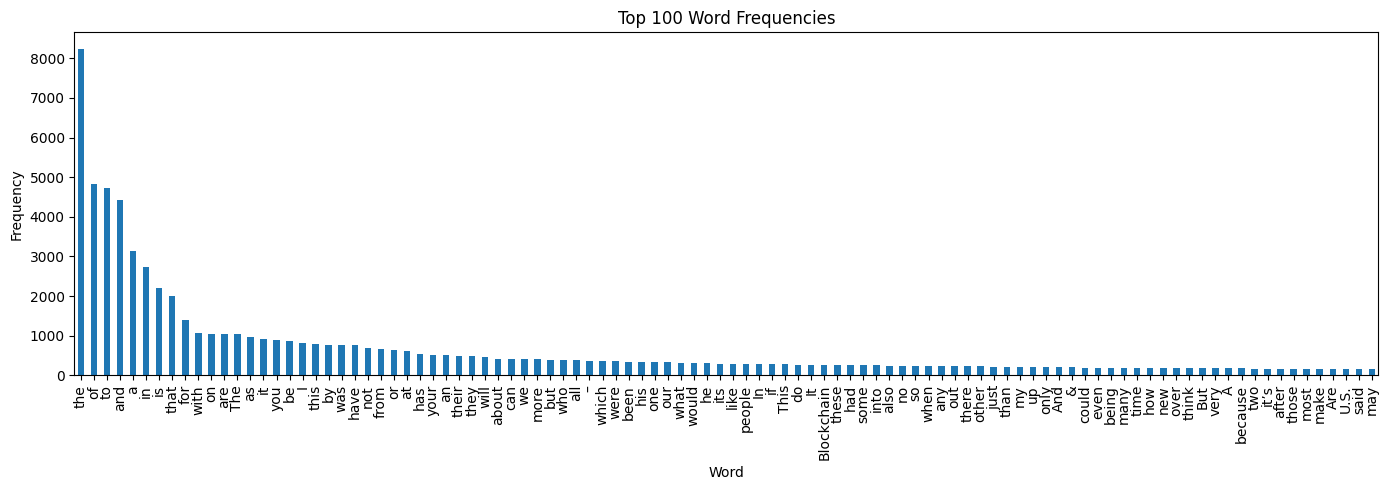

content
the     8244
of      4826
to      4722
and     4414
a       3141
        ... 
make     156
Are      156
U.S.     152
said     148
may      148
Name: count, Length: 100, dtype: int64

In [40]:
# Asger
def visualize_top_words(
    df: pd.DataFrame,
    token_col: str,
    top_n: int = 10_000,
    loglog: bool = True
):
    """
    df        : cleaned Pandas DataFrame
    token_col: column containing tokenized text (list of tokens per row)
    top_n    : number of most frequent words to visualize 
    
    If top_n <= 100 there will be put labels on for the x axis.
    """
    label_limit = 100
    # Flatten tokens
    col = df[token_col]
    
    if isinstance(col.iloc[0], str):
        tokens = col.str.split().explode()
    else:
        tokens = col.explode()
    
    tokens = tokens.dropna()
    counts = tokens.value_counts().head(top_n)

    # Plot
    plt.figure(figsize=(14, 5))

    if loglog:
        ranks = np.arange(1, len(counts) + 1)
        plt.loglog(ranks, counts.values)
        plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title("Word Frequency (Log-Log Scale)")
    else:
        if top_n <= label_limit:
            counts.plot(kind="bar")
            plt.xlabel("Word")
        else:
            plt.plot(counts.values)
            plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title(f"Top {len(counts)} Word Frequencies")

    plt.tight_layout()
    plt.show()

    return counts

visualize_top_words(df,'content',100,loglog=False)

In [7]:
# Mikkel
def data_split(X, y, train_frac = 0.8, test_frac = 0.1, val_frac = 0.1, stratify=None):
    '''
    Splits the data into a training, testing and validation set. The size fraction of each set
    can be specified.

    Returns a tuple containing features (X) and targets (y) for all sets.
    '''

    # Split the dataset into training and other (test + val) set.
    X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=(1-train_frac), stratify=stratify)

    # Split other into test and val set.
    X_test, X_val, y_test, y_val = train_test_split(X_other, y_other, test_size=(val_frac/(test_frac+val_frac)), stratify=stratify)

    return (X_train, X_test, X_val, y_train, y_test, y_val)